# Display of experiments

## Prepare the ressources

In [ ]:
!pip install pyagrum
!pip install numpy
!pip install causal-learn
!pip install pandas
!pip install bnlearn
!pip install graphviz
!pip install IPython
!pip install pgmpy

In [1]:
import sys
import os
sys.path.append(os.getcwd())

In [2]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb
import bnlearn as bn
import pgmpy
import graphviz
import numpy as np
from FCI import *
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import fisherz, gsq
from causallearn.utils.GraphUtils import GraphUtils
from IPython.display import Image, display

mr = gum.MeekRules()

C:\Users\vuale\AppData\Roaming\Python\Python313\site-packages\bnlearn\__init__.py:22: RuntimeWarning: [bnlearn] Using 'threading' backend instead of 'loky' because Windows + Python 3.13.2 causes joblib/loky crashes.
  warnings.warn(


## Experiment on a given available database

[bnlearn] >Import <asia>
[bnlearn] >Loading bif file <C:\Users\vuale\AppData\Roaming\Python\Python313\site-packages\datazets\data\asia.bif>
[bnlearn] >[CPD > Validate] >[Node asia] >OK
[bnlearn] >[CPD > Validate] >[Node bronc] >OK
[bnlearn] >[CPD > Validate] >[Node dysp] >OK
[bnlearn] >[CPD > Validate] >[Node either] >OK
[bnlearn] >[CPD > Validate] >[Node lung] >OK
[bnlearn] >[CPD > Validate] >[Node smoke] >OK
[bnlearn] >[CPD > Validate] >[Node tub] >OK
[bnlearn] >[CPD > Validate] >[Node xray] >OK
[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


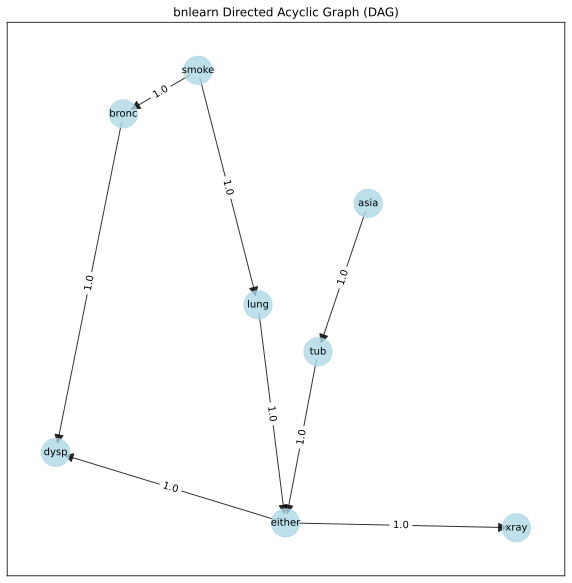

{'fig': <Figure size 2000x2000 with 1 Axes>,
 'ax': <Figure size 2000x2000 with 1 Axes>,
 'pos': {'asia': array([0.40955556, 0.12480256]),
  'tub': array([ 0.20955865, -0.03621838]),
  'either': array([ 0.08011342, -0.22191296]),
  'smoke': array([-0.26845163,  0.26921588]),
  'lung': array([-0.02927962,  0.01480106]),
  'bronc': array([-0.56584519,  0.22195569]),
  'dysp': array([-0.83565119, -0.14541701]),
  'xray': array([ 1.        , -0.22722684])},
 'G': <networkx.classes.digraph.DiGraph at 0x15f01e2e510>,
 'node_properties': {'asia': {'node_color': '#ADD8E6', 'node_size': 800},
  'tub': {'node_color': '#ADD8E6', 'node_size': 800},
  'smoke': {'node_color': '#ADD8E6', 'node_size': 800},
  'lung': {'node_color': '#ADD8E6', 'node_size': 800},
  'bronc': {'node_color': '#ADD8E6', 'node_size': 800},
  'either': {'node_color': '#ADD8E6', 'node_size': 800},
  'xray': {'node_color': '#ADD8E6', 'node_size': 800},
  'dysp': {'node_color': '#ADD8E6', 'node_size': 800}},
 'edge_properties': 

In [3]:
# bif_file= 'sprinkler' # 4 variables
# bif_file= 'alarm' # 37 variables
# bif_file= 'andes' # 223 variables
bif_file= 'asia' # 8 variables
# bif_file= 'sachs' # 11 variables
model = bn.import_DAG(bif_file)
bn.plot(model)

In [4]:
df = bn.sampling(model, n=100000)
df

,asia,tub,smoke,lung,bronc,either,xray,dysp
0,1,1,0,1,0,1,1,1
1,1,1,0,1,0,1,1,0
2,1,1,1,1,1,1,1,1
3,1,1,1,1,0,1,1,1
4,1,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...
99995,1,1,0,1,1,1,1,1
99996,1,1,0,1,0,1,1,0
99997,1,1,0,1,0,1,1,0
99998,1,1,1,1,1,1,1,0


In [5]:
tmp_variables = list(df.columns)
tmp_learner = gum.BNLearner(df, [])
G1, p1 = tmp_learner.G2(tmp_variables[0], tmp_variables[2], [tmp_variables[3]])
G2, p2, _ = pgmpy.estimators.CITests.g_sq(tmp_variables[0], tmp_variables[2], [tmp_variables[3]], df, boolean=False)
print((G1, p1))
print((G2, p2))

(6.53018817918143, 0.03819334131876193)
(np.float64(5.643320447277657), np.float64(0.05950706561559482))


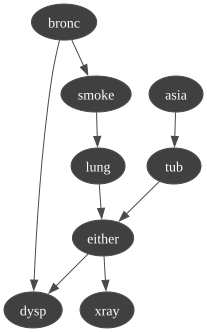

In [6]:
learner = gum.BNLearner(df)
learner.useMIIC()
bn_miic = learner.learnBN()
gnb.showBN(bn_miic)

  0%|          | 0/8 [00:00<?, ?it/s]

0 dep 1 | () with p-value 0.000000

0 dep 2 | () with p-value 0.039782

0 ind 3 | () with p-value 0.301780

0 ind 4 | () with p-value 0.243081

0 dep 5 | () with p-value 0.001400

0 ind 6 | () with p-value 0.055438

0 ind 7 | () with p-value 0.623015

1 dep 0 | () with p-value 0.000000

1 ind 2 | () with p-value 0.458637

1 ind 3 | () with p-value 0.486698

1 ind 4 | () with p-value 0.609014

1 dep 5 | () with p-value 0.000000

1 dep 6 | () with p-value 0.000000

1 dep 7 | () with p-value 0.000000

2 dep 0 | () with p-value 0.039782

2 ind 1 | () with p-value 0.458637

2 dep 3 | () with p-value 0.000000

2 dep 4 | () with p-value 0.000000

2 dep 5 | () with p-value 0.000000

2 dep 6 | () with p-value 0.000000

2 dep 7 | () with p-value 0.000000

3 ind 0 | () with p-value 0.301780

3 ind 1 | () with p-value 0.486698

3 dep 2 | () with p-value 0.000000

3 dep 4 | () with p-value 0.000000

3 dep 5 | () with p-value 0.000000

3 dep 6 | () with p-value 0.000000

3 dep 7 | () with p-value 0.

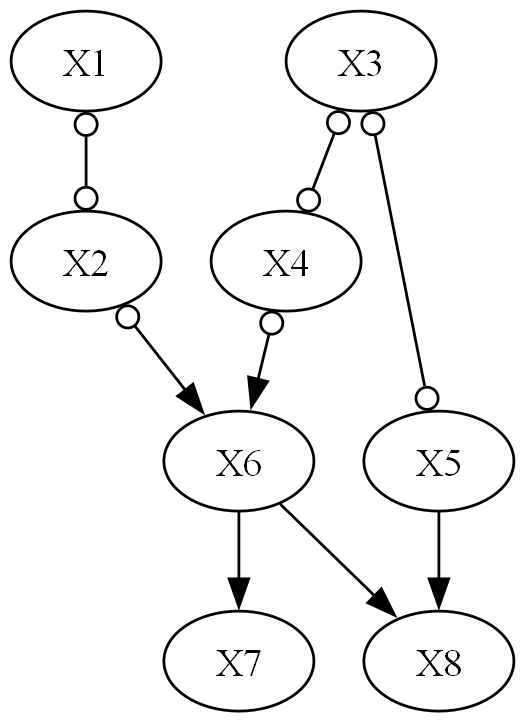

In [7]:
graph, sep_sets = fci(
    df.to_numpy(),
    ci_test=gsq,
    alpha=0.05,
    verbose=True,
)
node_names = list(df.columns)
pdy = GraphUtils.to_pydot(graph)
display(Image(pdy.create_png()))

In [ ]:
fci_final_gum = run_FCI(df, 0.05, useGum=True)
print(fci_final_gum.matrix)
graph = fci_final_gum.toDot()
graph

[[' ' 'o' ' ' ' ' ' ' ' ' ' ' ' ']
 ['o' ' ' ' ' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' ' ' 'o' 'o' ' ' ' ' ' ']
 [' ' ' ' 'o' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' '-' ' ' ' ' ' ' ' ' '>']
 [' ' '-' ' ' '-' ' ' ' ' '>' '>']
 [' ' ' ' ' ' ' ' ' ' '-' ' ' ' ']
 [' ' ' ' ' ' ' ' 'o' '-' ' ' ' ']]


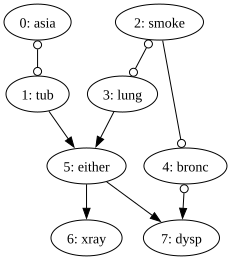

In [8]:
fci_final_pg = run_FCI(df, 0.05, useGum=False)
print(fci_final_pg.matrix)
graph = fci_final_pg.toDot()
graph

In [ ]:
rfci_gum = run_RFCI(df, 0.05, useGum=True)
print(rfci_gum.matrix)
graph = rfci_gum.toDot()
graph

[[' ' 'o' ' ' ' ' ' ' ' ' ' ' ' ']
 ['o' ' ' ' ' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' ' ' 'o' 'o' ' ' ' ' ' ']
 [' ' ' ' 'o' ' ' ' ' '>' ' ' ' ']
 [' ' ' ' '-' ' ' ' ' ' ' ' ' '>']
 [' ' '-' ' ' '-' ' ' ' ' '>' '>']
 [' ' ' ' ' ' ' ' ' ' '-' ' ' ' ']
 [' ' ' ' ' ' ' ' 'o' '-' ' ' ' ']]


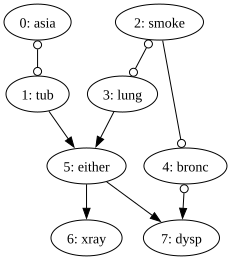

In [9]:
rfci_pg = run_RFCI(df, 0.05, useGum=False)
print(rfci_pg.matrix)
graph = rfci_pg.toDot()
graph

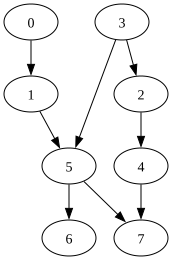

In [10]:
pdag = fci_final_pg.return_PDAG(opt = 1)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

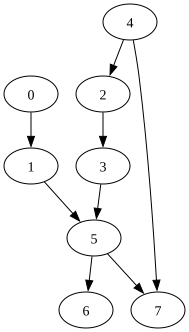

In [11]:
pdag = fci_final_pg.return_PDAG(opt = 2)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

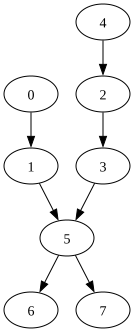

In [12]:
pdag = fci_final_pg.return_PDAG(opt = 3)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

In [ ]:
pdag = fci_final_gum.return_PDAG(opt=1)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

In [ ]:
pdag = fci_final_gum.return_PDAG(opt=2)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

In [ ]:
pdag = fci_final_gum.return_PDAG(opt=3)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

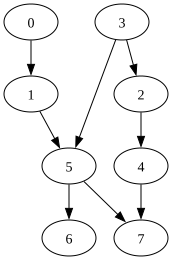

In [13]:
pdag = rfci_pg.return_PDAG(opt=1)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

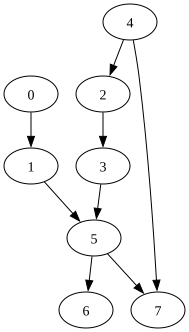

In [14]:
pdag = rfci_pg.return_PDAG(opt=2)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

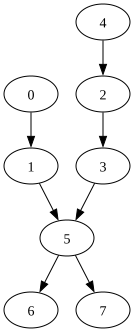

In [15]:
pdag = rfci_pg.return_PDAG(opt=3)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

In [ ]:
pdag = rfci_gum.return_PDAG(opt=1)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

In [ ]:
pdag = rfci_gum.return_PDAG(opt=2)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

In [ ]:
pdag = rfci_gum.return_PDAG(opt=3)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

## Experiment on a randomly generated database

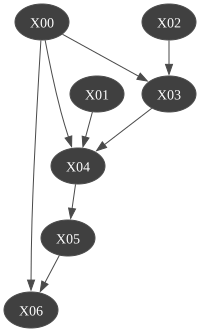

In [16]:
n = 7 # Modify this parameter
domain_size = 3 # Modify this parameter

bayesnet = gum.randomBN(n=n, domain_size=domain_size)
gnb.showBN(bayesnet)

In [17]:
g = gum.BNDatabaseGenerator(bayesnet)
g.setRandomVarOrder()
g.setDiscretizedLabelModeRandom()
g.drawSamples(100000)
df = g.to_pandas()
for col in df.columns:
    df[col] = df[col].astype('category').cat.codes
df

,X03,X04,X00,X05,X01,X02,X06
0,0,2,0,2,0,1,1
1,0,2,0,1,1,0,0
2,2,0,1,0,2,2,1
3,1,2,0,1,1,2,2
4,0,1,0,2,1,0,2
...,...,...,...,...,...,...,...
99995,1,2,0,1,2,2,2
99996,2,2,0,0,1,1,1
99997,0,0,0,2,0,0,0
99998,1,0,0,0,0,1,2


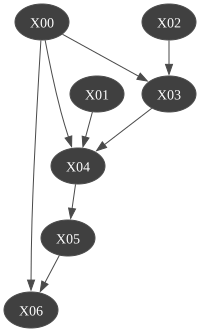

In [18]:
learner = gum.BNLearner(df)
learner.useMIIC()
bn_miic = learner.learnBN()
gnb.showBN(bn_miic)

  0%|          | 0/7 [00:00<?, ?it/s]

0 dep 1 | () with p-value 0.000000

0 dep 2 | () with p-value 0.000000

0 ind 3 | () with p-value 0.592659

0 ind 4 | () with p-value 0.861900

0 dep 5 | () with p-value 0.000000

0 ind 6 | () with p-value 0.892321

1 dep 0 | () with p-value 0.000000

1 ind 2 | () with p-value 0.219854

1 dep 3 | () with p-value 0.000000

1 dep 4 | () with p-value 0.000000

1 dep 5 | () with p-value 0.000000

1 dep 6 | () with p-value 0.000000

2 dep 0 | () with p-value 0.000000

2 ind 1 | () with p-value 0.219854

2 dep 3 | () with p-value 0.012621

2 ind 4 | () with p-value 0.412943

2 ind 5 | () with p-value 0.822695

2 ind 6 | () with p-value 0.618037

3 ind 0 | () with p-value 0.592659

3 dep 1 | () with p-value 0.000000

3 dep 2 | () with p-value 0.012621

3 dep 4 | () with p-value 0.000000

3 dep 5 | () with p-value 0.018202

3 dep 6 | () with p-value 0.000000

4 ind 0 | () with p-value 0.861900

4 dep 1 | () with p-value 0.000000

4 ind 2 | () with p-value 0.412943

4 dep 3 | () with p-value 0.

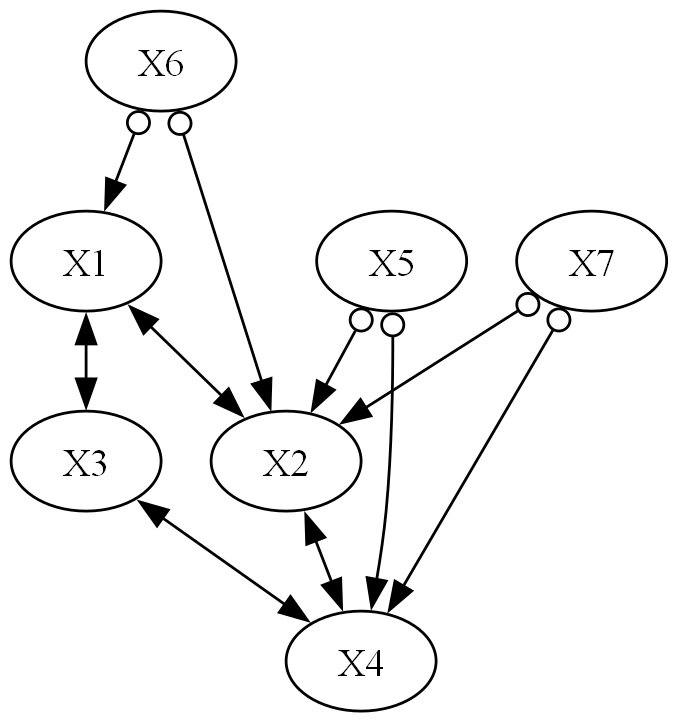

In [19]:
graph, sep_sets = fci(
    df.to_numpy(),
    ci_test=gsq,
    alpha=0.05,
    verbose=True,
)
node_names = list(df.columns)
pdy = GraphUtils.to_pydot(graph)
display(Image(pdy.create_png()))

[[' ' '>' 'o' ' ' ' ' 'o' ' ']
 ['-' ' ' '-' '>' 'o' ' ' ' ']
 ['>' '>' ' ' ' ' ' ' ' ' '>']
 [' ' '-' ' ' ' ' ' ' ' ' '>']
 [' ' '>' ' ' ' ' ' ' ' ' ' ']
 ['>' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' 'o' '-' ' ' ' ' ' ']]


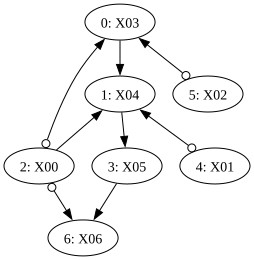

In [20]:
fci_final_pg = run_FCI(df, 0.05, useGum=False, bayesnet=bayesnet)
print(fci_final_pg.matrix)
graph = fci_final_pg.toDot()
graph

[[' ' '>' 'o' ' ' ' ' 'o' ' ']
 ['-' ' ' '-' '>' 'o' ' ' ' ']
 ['>' '>' ' ' ' ' ' ' ' ' '>']
 [' ' '-' ' ' ' ' ' ' ' ' '>']
 [' ' '>' ' ' ' ' ' ' ' ' ' ']
 ['>' ' ' ' ' ' ' ' ' ' ' ' ']
 [' ' ' ' 'o' '-' ' ' ' ' ' ']]


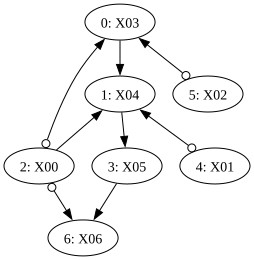

In [21]:
rfci_pg = run_FCI(df, 0.05, useGum=False, bayesnet=bayesnet)
print(rfci_pg.matrix)
graph = rfci_pg.toDot()
graph

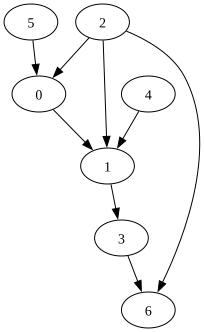

In [22]:
pdag = fci_final_pg.return_PDAG(opt=1)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

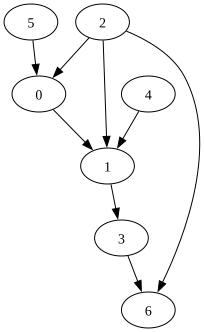

In [23]:
pdag = fci_final_pg.return_PDAG(opt=2)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

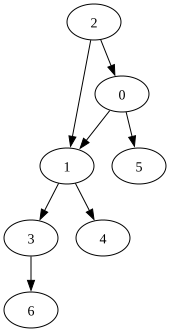

In [24]:
pdag = fci_final_pg.return_PDAG(opt=3)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

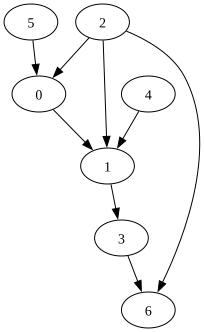

In [25]:
pdag = rfci_pg.return_PDAG(opt=1)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

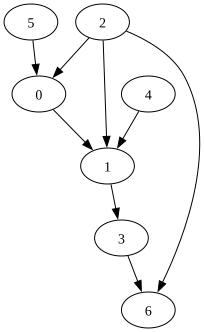

In [26]:
pdag = rfci_pg.return_PDAG(opt=2)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph

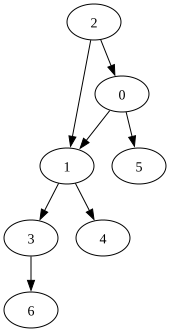

In [27]:
pdag = rfci_pg.return_PDAG(opt=3)
dag = mr.propagateToDAG(pdag)
graph = graphviz.Source(dag.toDot())
graph